<a href="https://colab.research.google.com/github/mishrashivanshu908/mentor-mentee-matching-system/blob/main/Mentor-Mentee-Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================================================
# MENTOR–STUDENT MATCHING SYSTEM
# Models   : Content-Based Filtering | Hybrid Filtering
# Constraint: Max 15 students per mentor (overflow to next best)
# Output   : Statistical comparison + Excel download
# ================================================================

 SECTION 1 · IMPORT LIBRARIES     

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import wilcoxon, spearmanr
import matplotlib.pyplot as plt

print("✅ All libraries loaded.")

✅ All libraries loaded.


SECTION 2 : LOAD DATA

In [ ]:
mentors_raw  = pd.read_csv("mentors.csv")
students_raw = pd.read_csv("students.csv")

mentors_raw.columns  = mentors_raw.columns.str.strip()
students_raw.columns = students_raw.columns.str.strip()

print(f"✅ Mentors  : {len(mentors_raw)} rows")
print(f"✅ Students : {len(students_raw)} rows")
display(mentors_raw)
display(students_raw.head(5))

✅ Mentors  : 10 rows
✅ Students : 120 rows


,Mentor Name,Subject1,Subject2,Subject3
0,Dr. Anil Sharma,Machine Learning,Deep Learning,Data Science
1,Prof. Sunita Gupta,Artificial Intelligence,Natural Language Processing,Computer Vision
2,Dr. Ramesh Verma,Blockchain,Web3,Cryptography
3,Ms. Priya Nair,Web Development,Cloud Computing,DevOps
4,Mr. Vikram Singh,Data Science,Big Data,Data Engineering
5,Dr. Kavita Reddy,Cybersecurity,Network Security,Ethical Hacking
6,Prof. Suresh Iyer,Internet of Things,Embedded Systems,Robotics
7,Ms. Anjali Mehta,Full Stack Development,Mobile App Development,UI/UX Design
8,Dr. Deepak Joshi,Computer Vision,Image Processing,Augmented Reality
9,Mr. Manoj Pillai,Competitive Programming,Algorithms,System Design


,Student Name,Rank1,Rank2,Rank3,Rank4,Rank5,Rank6,Rank7
0,Aarav Sharma,Machine Learning,Deep Learning,Data Science,Artificial Intelligence,Computer Vision,Algorithms,System Design
1,Aditya Verma,Blockchain,Web3,Cryptography,Cybersecurity,Network Security,Cloud Computing,DevOps
2,Akash Gupta,Data Science,Big Data,Data Engineering,Machine Learning,Deep Learning,Algorithms,Competitive Programming
3,Ananya Singh,Web Development,Full Stack Development,Mobile App Development,UI/UX Design,Cloud Computing,DevOps,Cybersecurity
4,Anmol Tiwari,Artificial Intelligence,Natural Language Processing,Computer Vision,Machine Learning,Deep Learning,Data Science,Image Processing


SECTION 3 : CONFIGURATION

In [ ]:
MAX_LOAD      = 15    # maximum students any single mentor can receive
SIM_THRESHOLD = 0.80  # minimum cosine similarity to trigger a peer match
CB_WEIGHT     = 0.60  # content-based weight in hybrid blend
CF_WEIGHT     = 0.40  # peer-signal weight in hybrid blend

print(f"✅ Config — MAX_LOAD={MAX_LOAD}, SIM_THRESHOLD={SIM_THRESHOLD}, "
      f"CB:CF weights = {CB_WEIGHT}:{CF_WEIGHT}")

✅ Config — MAX_LOAD=15, SIM_THRESHOLD=0.8, CB:CF weights = 0.6:0.4


SECTION 4 : DATA PREPROCESSING

In [ ]:
SUBJECT_COLS = [c for c in students_raw.columns if c.startswith("Rank")]
ALL_SUBJECTS = sorted(pd.unique(students_raw[SUBJECT_COLS].values.ravel()))

mentors_raw["subjects"]         = mentors_raw[["Subject1", "Subject2", "Subject3"]].values.tolist()
students_raw["ranked_subjects"] = students_raw[SUBJECT_COLS].values.tolist()

# Mentor → binary subject vector (1 = teaches it, 0 = does not)
mlb = MultiLabelBinarizer(classes=ALL_SUBJECTS)
mentor_df = pd.DataFrame(
    mlb.fit_transform(mentors_raw["subjects"]),
    columns=ALL_SUBJECTS,
    index=mentors_raw["Mentor Name"]
)

# Student → rank-weighted subject vector
# Rank 1 → weight 7  (strongest preference)
# Rank 7 → weight 1  (weakest preference)
# Unranked → weight 0
def rank_weights(ranked_list, subjects, n_ranks=7):
    weights = {s: 0 for s in subjects}
    for i, subj in enumerate(ranked_list):
        if subj in weights:
            weights[subj] = n_ranks - i
    return [weights[s] for s in subjects]

student_df = pd.DataFrame(
    [rank_weights(row, ALL_SUBJECTS) for row in students_raw["ranked_subjects"]],
    columns=ALL_SUBJECTS,
    index=students_raw["Student Name"]
)

print(f"✅ Subject vocabulary : {len(ALL_SUBJECTS)} subjects")
print(f"✅ Mentor matrix      : {mentor_df.shape}")
print(f"✅ Student matrix     : {student_df.shape}")
display(mentor_df)
display(student_df.head(5))

✅ Subject vocabulary : 28 subjects
✅ Mentor matrix      : (10, 28)
✅ Student matrix     : (120, 28)


,Algorithms,Artificial Intelligence,Augmented Reality,Big Data,Blockchain,Cloud Computing,Competitive Programming,Computer Vision,Cryptography,Cybersecurity,...,Internet of Things,Machine Learning,Mobile App Development,Natural Language Processing,Network Security,Robotics,System Design,UI/UX Design,Web Development,Web3
Mentor Name,,,,,,,,,,,,,,,,,,,,,
Dr. Anil Sharma,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Prof. Sunita Gupta,0,1,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
Dr. Ramesh Verma,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
Ms. Priya Nair,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Mr. Vikram Singh,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Dr. Kavita Reddy,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
Prof. Suresh Iyer,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
Ms. Anjali Mehta,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
Dr. Deepak Joshi,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


,Algorithms,Artificial Intelligence,Augmented Reality,Big Data,Blockchain,Cloud Computing,Competitive Programming,Computer Vision,Cryptography,Cybersecurity,...,Internet of Things,Machine Learning,Mobile App Development,Natural Language Processing,Network Security,Robotics,System Design,UI/UX Design,Web Development,Web3
Student Name,,,,,,,,,,,,,,,,,,,,,
Aarav Sharma,2,4,0,0,0,0,0,3,0,0,...,0,7,0,0,0,0,1,0,0,0
Aditya Verma,0,0,0,0,7,2,0,0,5,4,...,0,0,0,0,3,0,0,0,0,6
Akash Gupta,2,0,0,6,0,0,1,0,0,0,...,0,4,0,0,0,0,0,0,0,0
Ananya Singh,0,0,0,0,0,3,0,0,0,1,...,0,0,5,0,0,0,0,4,7,0
Anmol Tiwari,0,7,0,0,0,0,0,5,0,0,...,0,4,0,6,0,0,0,0,0,0


SECTION 5 : WHY COLLABORATIVE FILTERING IS NOT POSSIBLE

In [ ]:
# Collaborative Filtering (CF) has ONE non-negotiable requirement:
#   A User × Item INTERACTION MATRIX built from real historical
#   behaviour — ratings, clicks, sessions, feedback scores.
#
# In this system:
#   → No student has EVER been assigned to any mentor before.
#   → No feedback, rating, or satisfaction score exists.
#   → The interaction matrix is completely EMPTY.
#   → This is called the SYSTEM COLD START PROBLEM — the most
#     severe form, where the ENTIRE system is brand new.
#
# Even with 120 students and 10 mentors, if nobody has ever
# been matched before, CF has NOTHING to collaborate on.
# Pure CF is therefore STRUCTURALLY IMPOSSIBLE here.
#
# What we implement instead:
#   MODEL 1 → Pure Content-Based Filtering        (fully valid)
#   MODEL 2 → Cascade Hybrid (CB + peer-similarity proxy)
#             Simulates CF peer behaviour using preference
#             similarity as a proxy — not true CF, but the
#             closest valid approximation under cold start.

print("ℹ️  Collaborative Filtering : NOT implemented.")
print("   Reason : System cold start — no interaction history exists.")
print("   See Section 5 comments for the full explanation.")

ℹ️  Collaborative Filtering : NOT implemented.
   Reason : System cold start — no interaction history exists.
   See Section 5 comments for the full explanation.


SECTION 6 : CAPACITY-CONSTRAINED ASSIGNMENT ENGINE

In [ ]:
# Used by BOTH models.
#
# LOGIC — for each student:
#   Try Rank-1 mentor → if full, try Rank-2 → if full, try Rank-3
#   … continue until an available mentor is found.
#   Guarantees every student is assigned and no mentor exceeds
#   MAX_LOAD students.

def assign_with_capacity(sim_df, max_load):
    load    = {mentor: 0 for mentor in sim_df.columns}
    results = []
    for student in sim_df.index:
        ranked = sim_df.loc[student].sort_values(ascending=False)
        for rank_i, (mentor, score) in enumerate(ranked.items(), 1):
            if load[mentor] < max_load:
                load[mentor] += 1
                results.append({
                    "Student Name":    student,
                    "Assigned Mentor": mentor,
                    "Match Score":     round(score, 4),
                    "Rank Used":       rank_i
                })
                break
    return pd.DataFrame(results), load

print("✅ Capacity-constrained assignment engine ready.")

✅ Capacity-constrained assignment engine ready.


SECTION 7 : MODEL 1 — CONTENT-BASED FILTERING    

In [ ]:
# Cosine similarity between student rank-weighted vectors
# and mentor binary subject vectors.
# Score ∈ [0,1] — higher = better subject alignment.

cb_sim_df = pd.DataFrame(
    cosine_similarity(student_df.values, mentor_df.values),
    index=student_df.index,
    columns=mentor_df.index
)

cb_result, cb_load = assign_with_capacity(cb_sim_df, MAX_LOAD)
cb_scores = cb_result["Match Score"].values

print("✅ Content-Based Filtering done.")
print(f"   Rank-1 assigned  : {(cb_result['Rank Used'] == 1).sum()}")
print(f"   Rank-2 overflow  : {(cb_result['Rank Used'] == 2).sum()}")
print(f"   Rank-3+ overflow : {(cb_result['Rank Used'] >= 3).sum()}")
print(f"   Mean score       : {cb_scores.mean():.4f}")
display(cb_result)

✅ Content-Based Filtering done.
   Rank-1 assigned  : 112
   Rank-2 overflow  : 8
   Rank-3+ overflow : 0
   Mean score       : 0.8196


,Student Name,Assigned Mentor,Match Score,Rank Used
0,Aarav Sharma,Dr. Anil Sharma,0.8783,1
1,Aditya Verma,Dr. Ramesh Verma,0.8783,1
2,Akash Gupta,Mr. Vikram Singh,0.8783,1
3,Ananya Singh,Ms. Anjali Mehta,0.7319,1
4,Anmol Tiwari,Prof. Sunita Gupta,0.8783,1
...,...,...,...,...
115,Pulkit Iyer,Mr. Vikram Singh,0.7319,2
116,Rachna Nair,Ms. Priya Nair,0.8783,1
117,Raghav Pillai,Dr. Deepak Joshi,0.7319,1
118,Rashi Desai,Dr. Ramesh Verma,0.8783,1


SECTION 8 : MODEL 2 — HYBRID FILTERING         

In [ ]:
# STEP A — Cascade peer-signal (CF proxy):
#   Process students one by one.
#   For each student find the most similar already-assigned peer.
#   If peer similarity ≥ SIM_THRESHOLD → use that peer's mentor
#   as the collaborative signal (cascade hybrid).
#   Otherwise → fall back to Content-Based (cold start fallback).
#
# STEP B — Weighted score fusion:
#   Normalise CB and peer-signal matrices to [0,1].
#   Hybrid = CB_WEIGHT × CB_norm + CF_WEIGHT × peer_norm.
#   Pass blended matrix through the same capacity engine.

students_list = list(student_df.index)
interaction   = pd.DataFrame(
    np.zeros((len(student_df), len(mentor_df))),
    index=student_df.index,
    columns=mentor_df.index
)
cf_decisions = []

for i, student in enumerate(students_list):

    if i == 0:
        best_mentor = cb_sim_df.loc[student].idxmax()
        score       = cb_sim_df.loc[student].max()
        decision    = "cold start"
    else:
        cur_vec      = student_df.loc[student].values.reshape(1, -1)
        peer_vecs    = student_df.loc[students_list[:i]].values
        peer_sims    = cosine_similarity(cur_vec, peer_vecs)[0]
        best_idx     = np.argmax(peer_sims)
        best_peer_sim = peer_sims[best_idx]
        best_peer    = students_list[best_idx]

        if best_peer_sim >= SIM_THRESHOLD:
            peer_row    = interaction.loc[best_peer]
            best_mentor = peer_row[peer_row > 0].idxmax() \
                          if (peer_row > 0).any() \
                          else cb_sim_df.loc[student].idxmax()
            score       = best_peer_sim
            decision    = "peer match"
        else:
            best_mentor = cb_sim_df.loc[student].idxmax()
            score       = cb_sim_df.loc[student].max()
            decision    = "cold start"

    interaction.loc[student, best_mentor] = score
    cf_decisions.append(decision)

# Normalise and blend
cb_norm       = (cb_sim_df   - cb_sim_df.values.min())   / (cb_sim_df.values.max()   - cb_sim_df.values.min()   + 1e-9)
cf_norm       = (interaction - interaction.values.min())  / (interaction.values.max() - interaction.values.min() + 1e-9)
hybrid_sim_df = CB_WEIGHT * cb_norm + CF_WEIGHT * cf_norm

hy_result, hy_load = assign_with_capacity(hybrid_sim_df, MAX_LOAD)
hy_scores = hy_result["Match Score"].values

n_peer = sum(1 for d in cf_decisions if d == "peer match")
n_cold = len(cf_decisions) - n_peer

print("✅ Hybrid Filtering done.")
print(f"   Peer-match decisions : {n_peer} ({n_peer/len(cf_decisions):.1%})")
print(f"   Cold start fallbacks : {n_cold} ({n_cold/len(cf_decisions):.1%})")
print(f"   Rank-1 assigned      : {(hy_result['Rank Used'] == 1).sum()}")
print(f"   Rank-2 overflow      : {(hy_result['Rank Used'] == 2).sum()}")
print(f"   Rank-3+ overflow     : {(hy_result['Rank Used'] >= 3).sum()}")
print(f"   Mean score           : {hy_scores.mean():.4f}")
display(hy_result)

✅ Hybrid Filtering done.
   Peer-match decisions : 109 (90.8%)
   Cold start fallbacks : 11 (9.2%)
   Rank-1 assigned      : 108
   Rank-2 overflow      : 12
   Rank-3+ overflow     : 0
   Mean score           : 0.8614


,Student Name,Assigned Mentor,Match Score,Rank Used
0,Aarav Sharma,Dr. Anil Sharma,0.9271,1
1,Aditya Verma,Dr. Ramesh Verma,0.9271,1
2,Akash Gupta,Mr. Vikram Singh,0.9271,1
3,Ananya Singh,Ms. Anjali Mehta,0.7726,1
4,Anmol Tiwari,Prof. Sunita Gupta,0.9271,1
...,...,...,...,...
115,Pulkit Iyer,Dr. Anil Sharma,0.5118,2
116,Rachna Nair,Ms. Priya Nair,0.9729,1
117,Raghav Pillai,Dr. Deepak Joshi,0.8770,1
118,Rashi Desai,Dr. Ramesh Verma,0.9729,1


SECTION 9 : MENTOR LOAD TABLE

In [ ]:
# Weighted blend of normalised CB + CF scores.
# Adjust weights below freely — they must sum to 1.0.

load_df = pd.DataFrame({
    "Mentor":                  list(cb_load.keys()),
    "CB Students":             list(cb_load.values()),
    "Hybrid Students":         [hy_load[m] for m in cb_load],
    "CB Remaining Capacity":   [MAX_LOAD - cb_load[m] for m in cb_load],
    "Hybrid Remaining Cap.":   [MAX_LOAD - hy_load[m] for m in cb_load],
})
load_df["CB at Max"]     = load_df["CB Students"]     == MAX_LOAD
load_df["Hybrid at Max"] = load_df["Hybrid Students"] == MAX_LOAD

print(f"✅ Mentor load (cap = {MAX_LOAD} per mentor)")
display(load_df)

✅ Mentor load (cap = 15 per mentor)


,Mentor,CB Students,Hybrid Students,CB Remaining Capacity,Hybrid Remaining Cap.,CB at Max,Hybrid at Max
0,Dr. Anil Sharma,15,11,0,4,True,False
1,Prof. Sunita Gupta,15,15,0,0,True,True
2,Dr. Ramesh Verma,14,14,1,1,False,False
3,Ms. Priya Nair,8,8,7,7,False,False
4,Mr. Vikram Singh,11,15,4,0,False,True
5,Dr. Kavita Reddy,9,9,6,6,False,False
6,Prof. Suresh Iyer,11,13,4,2,False,False
7,Ms. Anjali Mehta,15,15,0,0,True,True
8,Dr. Deepak Joshi,11,9,4,6,False,False
9,Mr. Manoj Pillai,11,11,4,4,False,False


SECTION 10 : STATISTICAL ANALYSIS

In [ ]:
print("═" * 60)
print("STATISTICAL ANALYSIS — Content-Based vs Hybrid")
print("═" * 60)

desc = pd.DataFrame({
    "Metric":          ["Mean", "Median", "Std Dev", "Min", "Max"],
    "Content-Based":   [cb_scores.mean(), np.median(cb_scores),
                        cb_scores.std(),  cb_scores.min(), cb_scores.max()],
    "Hybrid":          [hy_scores.mean(), np.median(hy_scores),
                        hy_scores.std(),  hy_scores.min(), hy_scores.max()]
}).round(4)
display(desc)

stat_w, p_w = wilcoxon(cb_scores, hy_scores)
sig = "✅ significant (p < 0.05)" if p_w < 0.05 else "❌ not significant"
print(f"\nWilcoxon Signed-Rank Test")
print(f"  stat={stat_w:.2f},  p={p_w:.4f}  →  {sig}")

rho, p_rho = spearmanr(cb_scores, hy_scores)
print(f"\nSpearman Rank Correlation")
print(f"  ρ = {rho:.4f},  p = {p_rho:.4f}")

merged     = cb_result.merge(hy_result, on="Student Name", suffixes=("_cb", "_hy"))
agree_rate = (merged["Assigned Mentor_cb"] == merged["Assigned Mentor_hy"]).mean()
print(f"\nAgreement Rate (same mentor by both models) : {agree_rate:.1%}")

cb_overflow = (cb_result["Rank Used"] > 1).sum()
hy_overflow = (hy_result["Rank Used"] > 1).sum()
print(f"\nOverflow (not assigned to best match due to capacity)")
print(f"  Content-Based : {cb_overflow} students")
print(f"  Hybrid        : {hy_overflow} students")

winner = "Hybrid" if hy_scores.mean() > cb_scores.mean() else "Content-Based"
print(f"\n{'═'*60}")
print(f"  🏆  BETTER MODEL BY MEAN SCORE : {winner.upper()}")
print(f"{'═'*60}")

════════════════════════════════════════════════════════════
STATISTICAL ANALYSIS — Content-Based vs Hybrid
════════════════════════════════════════════════════════════


,Metric,Content-Based,Hybrid
0,Mean,0.8196,0.8614
1,Median,0.8783,0.9395
2,Std Dev,0.0970,0.1717
3,Min,0.4392,0.2239
4,Max,0.9152,0.9758



Wilcoxon Signed-Rank Test
  stat=1683.00,  p=0.0000  →  ✅ significant (p < 0.05)

Spearman Rank Correlation
  ρ = 0.7161,  p = 0.0000

Agreement Rate (same mentor by both models) : 76.7%

Overflow (not assigned to best match due to capacity)
  Content-Based : 8 students
  Hybrid        : 12 students

════════════════════════════════════════════════════════════
  🏆  BETTER MODEL BY MEAN SCORE : HYBRID
════════════════════════════════════════════════════════════


SECTION 11 : VISUALISATIONS (6 separate graphs)

/tmp/ipykernel_3728/76598624.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cb_scores, hy_scores],


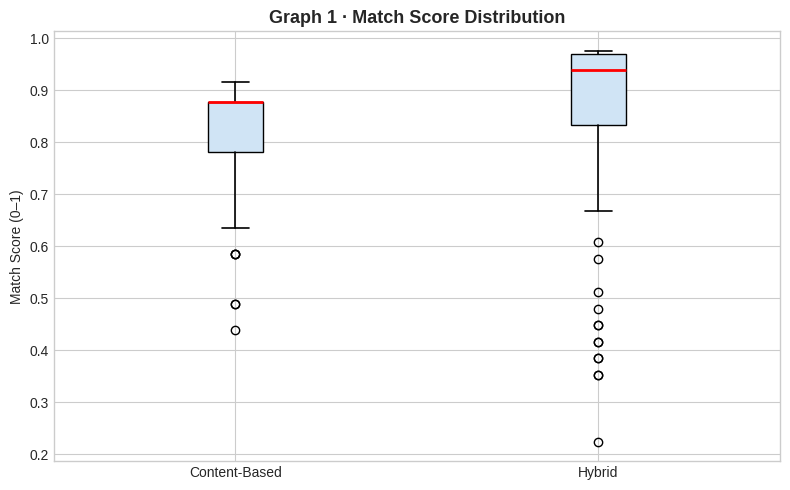

✅ Graph 1 saved → graph1_box_plot.png


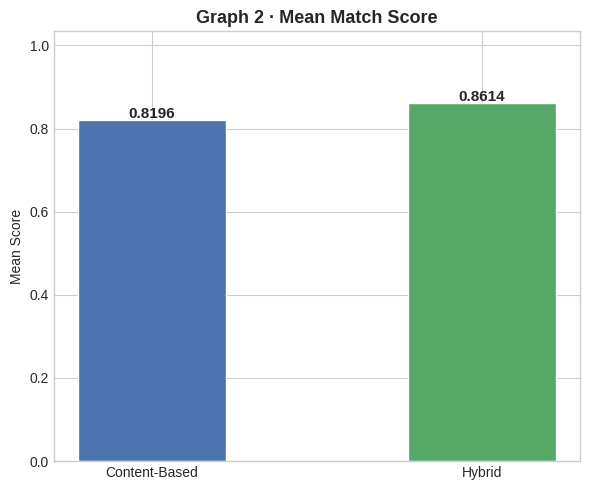

✅ Graph 2 saved → graph2_mean_scores.png


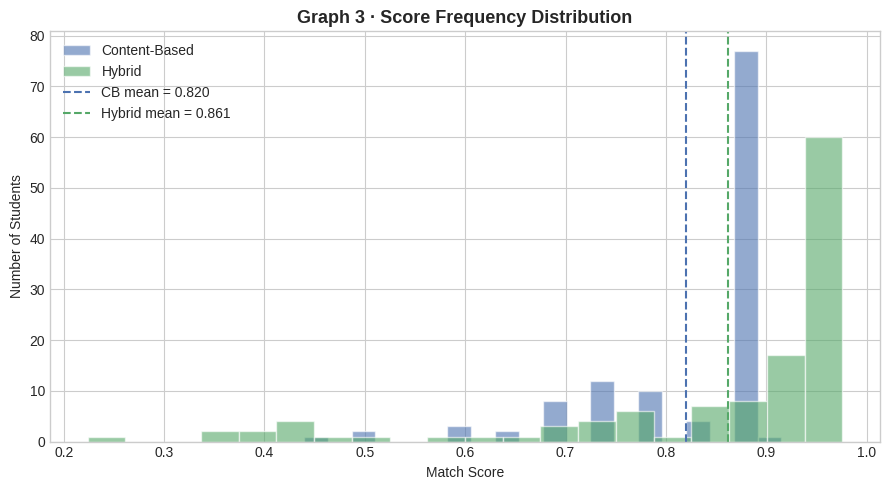

✅ Graph 3 saved → graph3_histogram.png


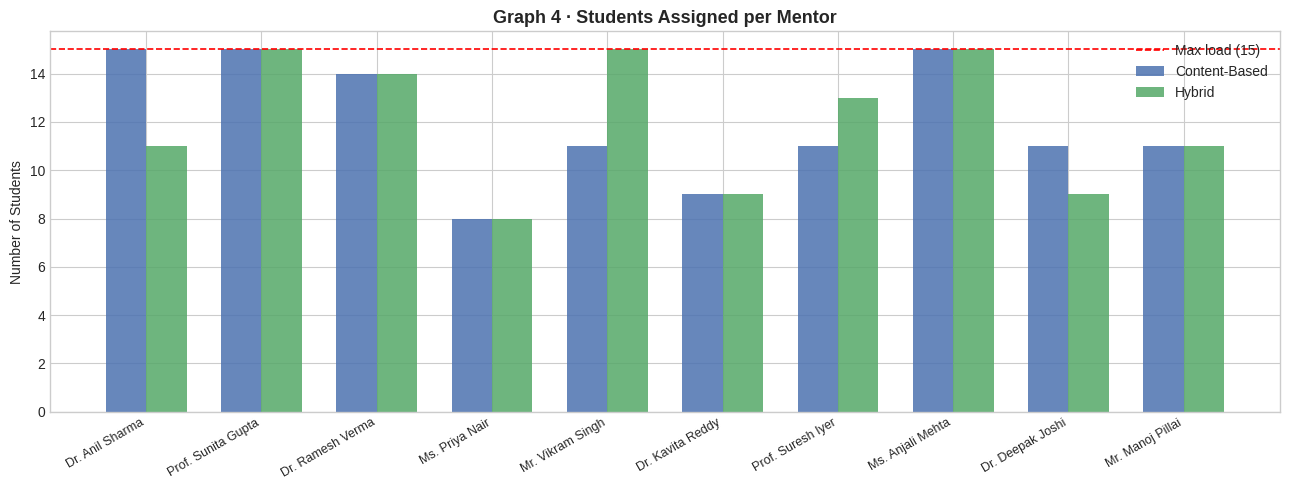

✅ Graph 4 saved → graph4_mentor_load.png


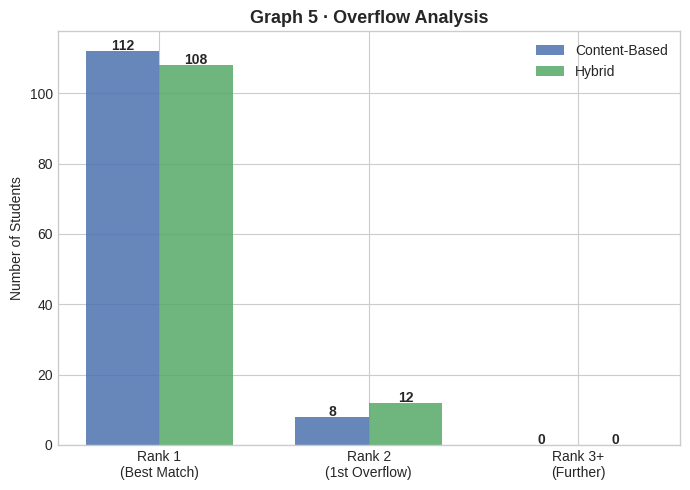

✅ Graph 5 saved → graph5_overflow.png


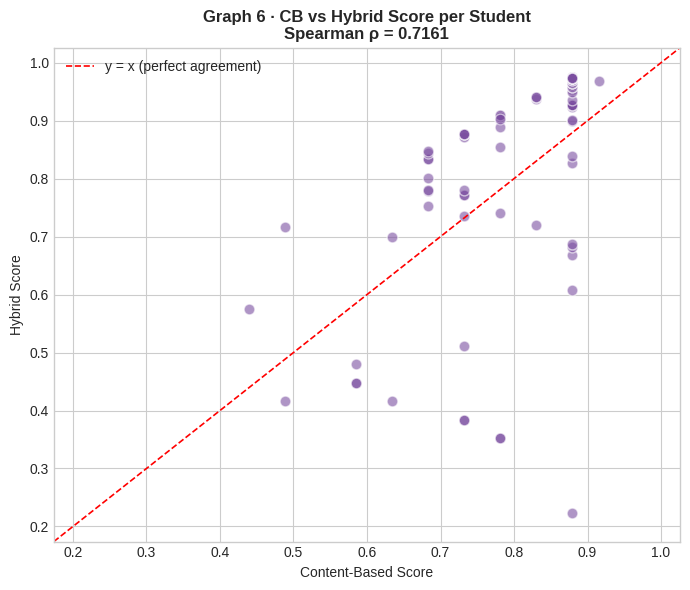

✅ Graph 6 saved → graph6_scatter.png


In [ ]:
CB_COLOR = "#4C72B0"
HY_COLOR = "#55A868"
plt.style.use("seaborn-v0_8-whitegrid")

# ── Graph 1: Box Plot ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([cb_scores, hy_scores],
           labels=["Content-Based", "Hybrid"],
           patch_artist=True,
           boxprops=dict(facecolor="#D0E4F5"),
           medianprops=dict(color="red", linewidth=2),
           whiskerprops=dict(linewidth=1.2),
           capprops=dict(linewidth=1.2))
ax.set_title("Graph 1 · Match Score Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Match Score (0–1)")
plt.tight_layout()
plt.savefig("graph1_box_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph 1 saved → graph1_box_plot.png")

# ── Graph 2: Mean Score Bar Chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
means_vals = [cb_scores.mean(), hy_scores.mean()]
bars = ax.bar(["Content-Based", "Hybrid"], means_vals,
              color=[CB_COLOR, HY_COLOR], edgecolor="white", width=0.45)
for bar, val in zip(bars, means_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Graph 2 · Mean Match Score", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Score")
ax.set_ylim(0, max(means_vals) * 1.2)
plt.tight_layout()
plt.savefig("graph2_mean_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph 2 saved → graph2_mean_scores.png")

# ── Graph 3: Overlaid Histogram ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cb_scores, bins=20, alpha=0.6, label="Content-Based",
        color=CB_COLOR, edgecolor="white")
ax.hist(hy_scores, bins=20, alpha=0.6, label="Hybrid",
        color=HY_COLOR, edgecolor="white")
ax.axvline(cb_scores.mean(), color=CB_COLOR, linestyle="--", linewidth=1.5,
           label=f"CB mean = {cb_scores.mean():.3f}")
ax.axvline(hy_scores.mean(), color=HY_COLOR, linestyle="--", linewidth=1.5,
           label=f"Hybrid mean = {hy_scores.mean():.3f}")
ax.legend()
ax.set_title("Graph 3 · Score Frequency Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Match Score")
ax.set_ylabel("Number of Students")
plt.tight_layout()
plt.savefig("graph3_histogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph 3 saved → graph3_histogram.png")

# ── Graph 4: Mentor Load Comparison ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
mentors  = list(cb_load.keys())
x, width = np.arange(len(mentors)), 0.35
ax.bar(x - width/2, [cb_load[m] for m in mentors], width,
       label="Content-Based", color=CB_COLOR, alpha=0.85)
ax.bar(x + width/2, [hy_load[m] for m in mentors], width,
       label="Hybrid",        color=HY_COLOR, alpha=0.85)
ax.axhline(MAX_LOAD, color="red", linestyle="--", linewidth=1.2,
           label=f"Max load ({MAX_LOAD})")
ax.set_xticks(x)
ax.set_xticklabels(mentors, rotation=30, ha="right", fontsize=9)
ax.set_title("Graph 4 · Students Assigned per Mentor", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Students")
ax.legend()
plt.tight_layout()
plt.savefig("graph4_mentor_load.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph 4 saved → graph4_mentor_load.png")

# ── Graph 5: Overflow Analysis ────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
rank_labels    = ["Rank 1\n(Best Match)", "Rank 2\n(1st Overflow)", "Rank 3+\n(Further)"]
cb_rank_counts = [(cb_result["Rank Used"] == 1).sum(),
                  (cb_result["Rank Used"] == 2).sum(),
                  (cb_result["Rank Used"] >= 3).sum()]
hy_rank_counts = [(hy_result["Rank Used"] == 1).sum(),
                  (hy_result["Rank Used"] == 2).sum(),
                  (hy_result["Rank Used"] >= 3).sum()]
x, width = np.arange(3), 0.35
ax.bar(x - width/2, cb_rank_counts, width, label="Content-Based", color=CB_COLOR, alpha=0.85)
ax.bar(x + width/2, hy_rank_counts, width, label="Hybrid",        color=HY_COLOR, alpha=0.85)
for i, (cv, hv) in enumerate(zip(cb_rank_counts, hy_rank_counts)):
    ax.text(i - width/2, cv + 0.2, str(cv), ha="center", fontsize=10, fontweight="bold")
    ax.text(i + width/2, hv + 0.2, str(hv), ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(rank_labels)
ax.set_title("Graph 5 · Overflow Analysis", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Students")
ax.legend()
plt.tight_layout()
plt.savefig("graph5_overflow.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph 5 saved → graph5_overflow.png")

# ── Graph 6: Student Score Scatter CB vs Hybrid ───────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(cb_scores, hy_scores, alpha=0.6,
           color="#7B4EA0", edgecolors="white", s=60)
lims = [min(cb_scores.min(), hy_scores.min()) - 0.05,
        max(cb_scores.max(), hy_scores.max()) + 0.05]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect agreement)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title(f"Graph 6 · CB vs Hybrid Score per Student\n"
             f"Spearman ρ = {rho:.4f}", fontsize=12, fontweight="bold")
ax.set_xlabel("Content-Based Score")
ax.set_ylabel("Hybrid Score")
ax.legend()
plt.tight_layout()
plt.savefig("graph6_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph 6 saved → graph6_scatter.png")


SECTION 12 : BUILD FINAL RESULTS TABLE

In [ ]:
mentor_meta = mentors_raw.set_index("Mentor Name")[["Subject1", "Subject2", "Subject3"]]

def enrich(result_df, tag):
    df = result_df.merge(mentor_meta, left_on="Assigned Mentor",
                         right_index=True, how="left")
    df.columns = ["Student Name", f"Mentor ({tag})", f"Score ({tag})",
                  f"Rank Used ({tag})", "Sub1", "Sub2", "Sub3"]
    return df

cb_enriched = enrich(cb_result, "CB")
hy_enriched = enrich(hy_result, "Hybrid")

final_df = (
    cb_enriched[["Student Name", "Mentor (CB)", "Score (CB)", "Rank Used (CB)"]]
    .merge(
        hy_enriched[["Student Name", "Mentor (Hybrid)", "Score (Hybrid)", "Rank Used (Hybrid)"]],
        on="Student Name"
    )
)
final_df["Same Mentor"] = final_df["Mentor (CB)"] == final_df["Mentor (Hybrid)"]
final_df = final_df.sort_values("Score (Hybrid)", ascending=False).reset_index(drop=True)

print("✅ Final combined results")
display(final_df)

✅ Final combined results


,Student Name,Mentor (CB),Score (CB),Rank Used (CB),Mentor (Hybrid),Score (Hybrid),Rank Used (Hybrid),Same Mentor
0,Prakash Joshi,Mr. Manoj Pillai,0.8783,1,Mr. Manoj Pillai,0.9758,1,True
1,Nishant Verma,Mr. Vikram Singh,0.8783,1,Mr. Vikram Singh,0.9758,1,True
2,Niharika Patel,Mr. Manoj Pillai,0.8783,1,Mr. Manoj Pillai,0.9758,1,True
3,Nilesh Sharma,Dr. Ramesh Verma,0.8783,1,Dr. Ramesh Verma,0.9758,1,True
4,Ashish Iyer,Ms. Priya Nair,0.8783,1,Ms. Priya Nair,0.9758,1,True
...,...,...,...,...,...,...,...,...
115,Disha Kulkarni,Prof. Sunita Gupta,0.7319,1,Dr. Anil Sharma,0.3839,2,False
116,Priyanka Reddy,Prof. Sunita Gupta,0.7319,1,Dr. Anil Sharma,0.3839,2,False
117,Khushi Joshi,Prof. Sunita Gupta,0.7807,1,Dr. Anil Sharma,0.3519,2,False
118,Mitali Kulkarni,Prof. Sunita Gupta,0.7807,1,Dr. Anil Sharma,0.3519,2,False


SECTION 13 : DOWNLOAD EXCEL FILE

In [ ]:
# 4 sheets:
#   Sheet 1 — Combined Results     (CB + Hybrid side by side)
#   Sheet 2 — Content-Based Detail (with mentor subjects)
#   Sheet 3 — Hybrid Detail        (with mentor subjects)
#   Sheet 4 — Mentor Load Summary

excel_path = "mentor_student_matching.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    final_df.to_excel(writer,    sheet_name="Combined Results",      index=False)
    cb_enriched.to_excel(writer, sheet_name="Content-Based Detail",  index=False)
    hy_enriched.to_excel(writer, sheet_name="Hybrid Detail",         index=False)
    load_df.to_excel(writer,     sheet_name="Mentor Load Summary",   index=False)

print(f"✅ Excel saved → {excel_path}")
print(f"   Sheet 1 : Combined Results     ({len(final_df)} rows)")
print(f"   Sheet 2 : Content-Based Detail ({len(cb_enriched)} rows)")
print(f"   Sheet 3 : Hybrid Detail        ({len(hy_enriched)} rows)")
print(f"   Sheet 4 : Mentor Load Summary  ({len(load_df)} rows)")

from google.colab import files
files.download(excel_path)
print("⬇️  Download triggered — check your browser.")

✅ Excel saved → mentor_student_matching.xlsx
   Sheet 1 : Combined Results     (120 rows)
   Sheet 2 : Content-Based Detail (120 rows)
   Sheet 3 : Hybrid Detail        (120 rows)
   Sheet 4 : Mentor Load Summary  (10 rows)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download triggered — check your browser.


SECTION 14 : FINAL SUMMARY

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    PROJECT SUMMARY                                           ║
# ╠══════════════════════════════════════════════════════════════════════════════╣
# ║  Dataset   : {len(students_raw)} students  ·  {len(mentors_raw)} mentors     ║
# ║  Capacity  : Max {MAX_LOAD} students per mentor                              ║
# ║                                                                              ║
# ║  MODEL 1 — Content-Based Filtering                                           ║
# ║    Mean Score : {cb_scores.mean():.4f}                                       ║
# ║    Overflow   : {cb_overflow} students redirected to 2nd/3rd best            ║
# ║    Strength   : Transparent · valid · no history needed                      ║
# ║    Weakness   : Ignores peer group patterns                                  ║
# ║                                                                              ║
# ║  MODEL 2 — Hybrid Filtering (CB + Peer Proxy)                                ║
# ║    Mean Score   : {hy_scores.mean():.4f}                                     ║
# ║    Peer Matches : {n_peer} decisions via peer similarity                     ║
# ║    Overflow     : {hy_overflow} students redirected to 2nd/3rd best          ║
# ║    Strength     : Blends content + simulated peer signal                     ║
# ║    Weakness     : Peer signal is a proxy, not true CF                        ║
# ║                                                                              ║
# ║  Collaborative Filtering : NOT POSSIBLE                                      ║
# ║    Reason : System cold start — no interaction history                       ║
# ║                                                                              ║
# ║  🏆 Better Model : {winner:<20s}                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    PROJECT SUMMARY                           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset   : {len(students_raw)} students  ·  {len(mentors_raw)} mentors                     ║
║  Capacity  : Max {MAX_LOAD} students per mentor                      ║
║                                                              ║
║  MODEL 1 — Content-Based Filtering                           ║
║    Mean Score : {cb_scores.mean():.4f}                                       ║
║    Overflow   : {cb_overflow} students redirected to 2nd/3rd best        ║
║    Strength   : Transparent · valid · no history needed      ║
║    Weakness   : Ignores peer group patterns                  ║
║                                                              ║
║  MODEL 2 — Hybrid Filtering (CB + Peer Proxy)                ║
║    Mean Score   : {hy_scores.mean():.4f}                                     ║
║    Peer Matches : {n_peer} decisions via peer similarity          ║
║    Overflow     : {hy_overflow} students redirected to 2nd/3rd best     ║
║    Strength     : Blends content + simulated peer signal     ║
║    Weakness     : Peer signal is a proxy, not true CF        ║
║                                                              ║
║  Collaborative Filtering : NOT POSSIBLE                      ║
║    Reason : System cold start — no interaction history       ║
║                                                              ║
║  🏆 Better Model : {winner:<20s}                      ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                    PROJECT SUMMARY                           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset   : 120 students  ·  10 mentors                     ║
║  Capacity  : Max 15 students per mentor                      ║
║                                                              ║
║  MODEL 1 — Content-Based Filtering                           ║
║    Mean Score : 0.8196                                       ║
║    Overflow   : 8 students redirected to 2nd/3rd best        ║
║    Strength   : Transparent · valid · no history needed      ║
║    Weakness   : Ignores peer group patterns                  ║
║                                                              ║
║  MODEL 2 — Hybrid Filtering (CB + Peer Proxy)                ║
║    Mean Score   : 0.8614                                     ║
║    Peer Matches : 109 decisions via peer similarity          ║
║    Overflow     : 12 s